# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Muhammad Dzaky Haidar              |5054251039       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
df = pd.read_csv("WineQT.csv")

#Ngedrop Kolom ID
df = df.drop(columns=["Id"], errors="ignore")

print("Jumlah Baris dan Kolom:", df.shape)
display(df.head())
df.info()
display(df.describe)
print("\nJumlah Missing Value:")
print(df.isna().sum())
print("\nJumlah Duplikat:", df.duplicated().sum())

Jumlah Baris dan Kolom: (1143, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


<bound method NDFrame.describe of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                    11.0                  34.0  0.99780  3.51       0.56   
1                    25.0                  67.0  0.99680  3.20       0.68   
2                    15.0                  54.0  0.99700  3.26       0.65   
3                    17.0                  60.0  0.99800  3.16       0.58   
4                    11.0                  34.0  0.99780  3.51       0.56   
...                   ...                   ...      ...   ...        ...   
1138                 29.0                  40.0  0.99574  3.42       0.75   
1139                 28.0                  38.0  0.99651  3.42       0.82   
1140                 32.0                  44.0  0.99490  3.45       0.58   
1141                 39.0                  51.0  0.99512  3.52       0.76   
1142                 32.0                  44.0  0.99547  3.57       0.71   

      alcohol  quality  
0         9.4        5  
1         9.8        5  
2         9.8        5  
3         9.8        6  
4         9.4        5  
...       ...      ...  
1138     11.0        6  
1139      9.5        6  
1140     10.5        5  
1141     11.2        6  
1142     10.2        5  

[1143 rows x 12 columns]>


Jumlah Missing Value:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Jumlah Duplikat: 125


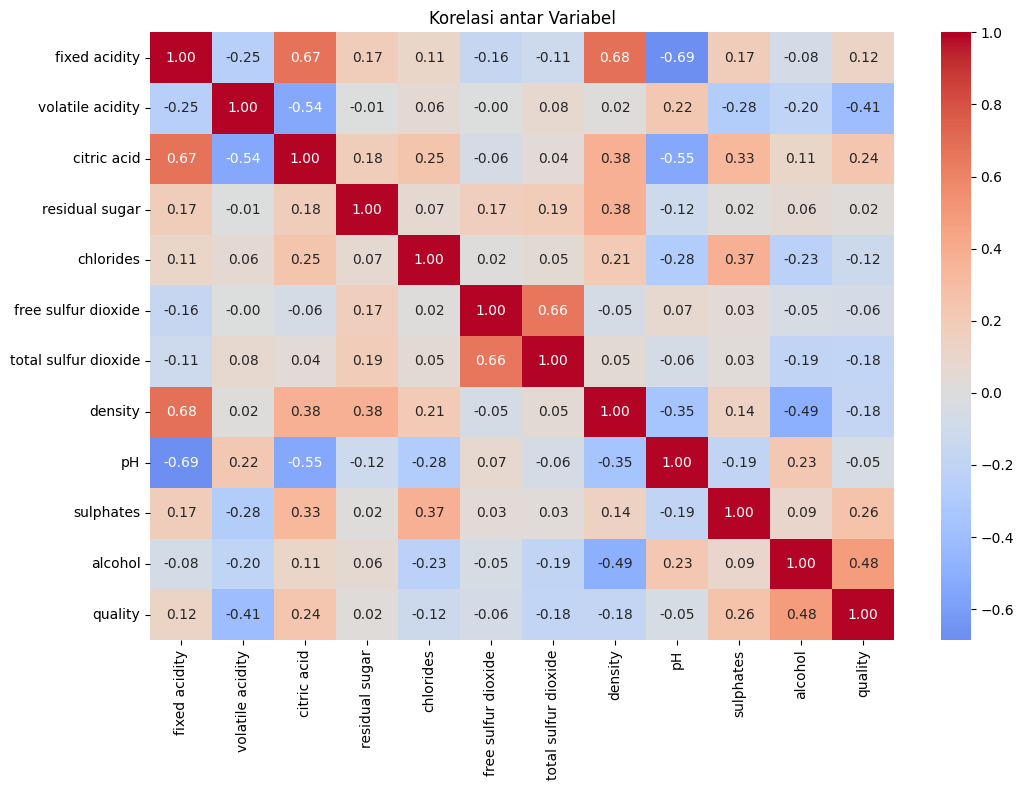

In [3]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(11,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi antar Variabel")
plt.tight_layout()
plt.show()

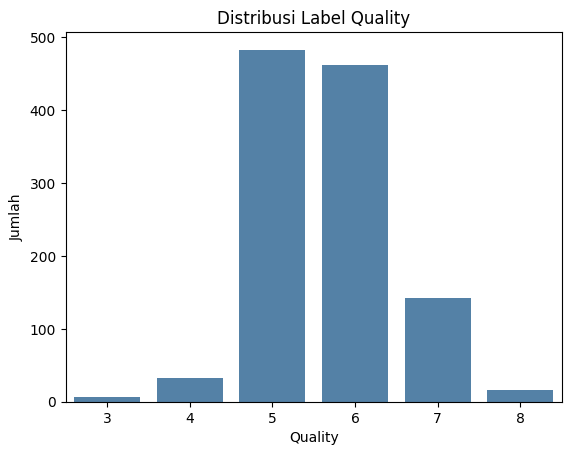

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [4]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
sns.countplot(data=df, x="quality", color="steelblue")
plt.title("Distribusi Label Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah")
plt.show()

print(df["quality"].value_counts().sort_index())

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan.

# 2. Preprocessing




In [5]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["quality"])
df = df.drop_duplicates().reset_index(drop=True)
df["quality"] = df["quality"].astype(int)

print(df.shape)
print("Sisa Duplicate:", df.duplicated().sum())

(1018, 12)
Sisa Duplicate: 0


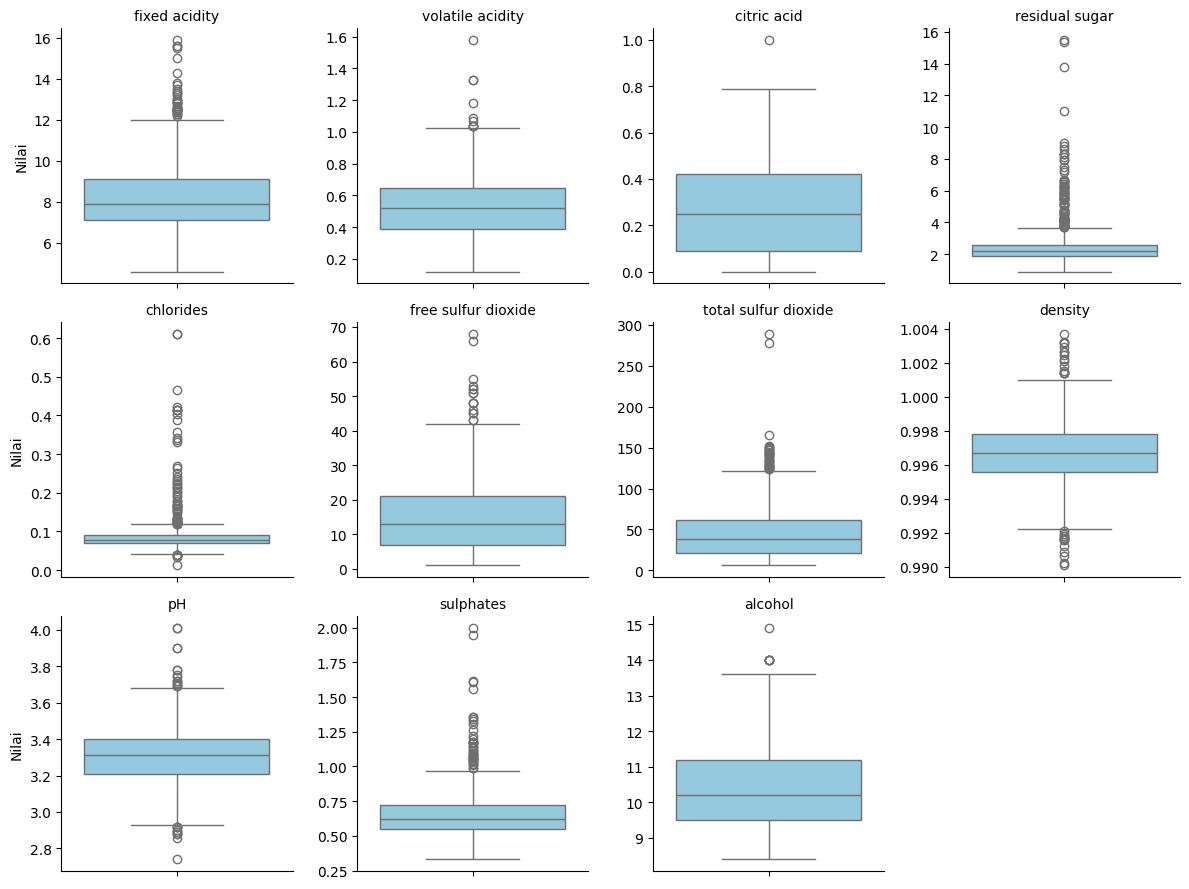

In [6]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
df_melt = df.drop(columns="quality").melt(var_name="Fitur", value_name="Nilai")
g = sns.FacetGrid(df_melt, col='Fitur', col_wrap=4, sharey=False, height=3)
g.map_dataframe(sns.boxplot, y="Nilai", color="skyblue")
g.set_titles("{col_name}")
plt.tight_layout
plt.show()


In [7]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
preprocessor = make_pipeline(
    SimpleImputer(strategy="median"),StandardScaler()
)

# 3. Eksperimen Model KNN


In [8]:
# Split 80% train dan 20% test
X = df.drop(columns="quality")
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Fit imputasi dan scaling hanya pada train
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Eksperimen parameter KNN
hasil = []

for k in range(1, 102, 2):
    for metric in ["euclidean", "manhattan"]:
        for weights in ["uniform", "distance"]:
            model = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric,
                weights=weights
            )
            model.fit(X_train_scaled, y_train)

            hasil.append({
                "k": k,
                "metric": metric,
                "weights": weights,
                "Accuracy Train": model.score(X_train_scaled, y_train),
                "Accuracy Test": model.score(X_test_scaled, y_test)
            })

hasil = pd.DataFrame(hasil).sort_values(
    "Accuracy Test", ascending=False, kind="stable"
).reset_index(drop=True)

display(hasil.head(10))

# Gunakan parameter dengan skor test tertinggi dalam eksperimen
best = hasil.iloc[0]

knn = KNeighborsClassifier(
    n_neighbors=int(best["k"]),
    metric=best["metric"],
    weights=best["weights"]
)
knn.fit(X_train_scaled, y_train)

print(f"Train: {len(y_train)} sampel")
print(f"Test : {len(y_test)} sampel")

print("\nParameter terpilih:")
print(f"k       : {knn.n_neighbors}")
print(f"Metric  : {knn.metric}")
print(f"Weights : {knn.weights}")

,k,metric,weights,Accuracy Train,Accuracy Test
0,19,euclidean,distance,1.000000,0.612745
1,25,euclidean,distance,1.000000,0.607843
2,29,euclidean,distance,1.000000,0.607843
3,27,euclidean,distance,1.000000,0.602941
4,19,euclidean,uniform,0.604423,0.598039
5,31,euclidean,distance,1.000000,0.598039
6,31,manhattan,distance,1.000000,0.598039
7,53,euclidean,distance,1.000000,0.598039
8,23,euclidean,distance,1.000000,0.593137
9,39,manhattan,uniform,0.613022,0.593137


Train: 814 sampel
Test : 204 sampel

Parameter terpilih:
k       : 19
Metric  : euclidean
Weights : distance


# 4. Evaluasi Model


,Accuracy,Precision Macro,Recall Macro,F1 Macro
Data,,,,
Train,1.0000,1.0000,1.000,1.000
Test,0.6127,0.2965,0.301,0.298


Classification Report — Test:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.69      0.70      0.69        87
           6       0.57      0.65      0.61        82
           7       0.52      0.46      0.49        24
           8       0.00      0.00      0.00         3

    accuracy                           0.61       204
   macro avg       0.30      0.30      0.30       204
weighted avg       0.58      0.61      0.60       204



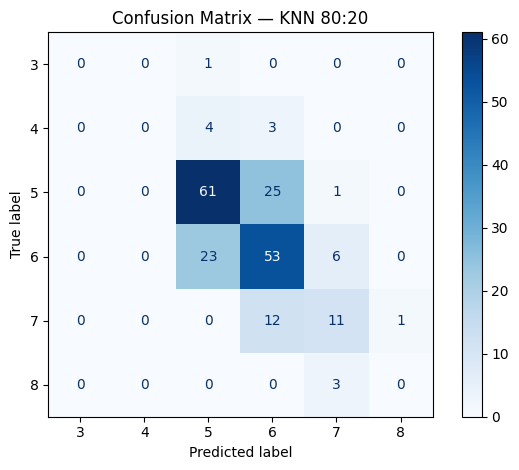

In [9]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
evaluasi = []

for nama, X_set, y_set in [
    ("Train", X_train_scaled, y_train),
    ("Test", X_test_scaled, y_test)
]:
    pred = knn.predict(X_set)

    evaluasi.append({
        "Data": nama,
        "Accuracy": accuracy_score(y_set, pred),
        "Precision Macro": precision_score(
            y_set, pred, average="macro", zero_division=0
        ),
        "Recall Macro": recall_score(
            y_set, pred, average="macro", zero_division=0
        ),
        "F1 Macro": f1_score(
            y_set, pred, average="macro", zero_division=0
        )
    })

display(pd.DataFrame(evaluasi).set_index("Data").round(4))

y_pred = knn.predict(X_test_scaled)

print("Classification Report — Test:")
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Blues"
)

plt.title("Confusion Matrix — KNN 80:20")
plt.tight_layout()
plt.show()

# 5. Analisis

## Analisis

1. Dataset awal berisi 1.143 sampel. Setelah kolom `Id` dihapus dan 125 data duplikat dibuang, tersisa 1.018 sampel dengan 11 fitur dan satu target, yaitu `quality`.

2. Tidak ditemukan missing value, sehingga imputasi median tidak mengubah data. StandardScaler dipelajari hanya dari data train, kemudian digunakan untuk mentransformasi data test.

3. Data dibagi menjadi 814 sampel train dan 204 sampel test dengan perbandingan 80:20. Penggunaan `stratify=y` menjaga proporsi kelas pada kedua bagian data.

4. Dari 204 kombinasi parameter, akurasi test tertinggi diperoleh pada **k=19, metric Euclidean, dan weights distance**, yaitu **61,27%**. Kombinasi k=25 dan k=29 dengan metric serta weights yang sama menghasilkan akurasi **60,78%**.

5. Pada k=19 dan metric Euclidean, weights uniform menghasilkan akurasi **59,80%**. Dalam eksperimen ini, pemberian bobot lebih besar kepada tetangga yang lebih dekat memberikan hasil lebih baik.

6. Akurasi train mencapai **100%**, sedangkan akurasi test sebesar **61,27%**. Pada KNN dengan weights distance, sampel train dapat menjadi tetangga dirinya sendiri dengan jarak nol. Karena itu, akurasi train yang sempurna tidak menunjukkan kemampuan prediksi yang sempurna pada data baru.

7. Model lebih berhasil mengenali kelas 5 dan 6, dengan F1-score masing-masing **0,69** dan **0,61**. Kelas 7 memperoleh F1-score **0,49**, sedangkan kelas 3, 4, dan 8 belum berhasil dikenali dengan benar. Jumlah sampel test pada ketiga kelas tersebut juga sedikit.

8. F1 macro sebesar **0,298** menunjukkan bahwa performa antar kelas belum merata. Parameter juga dipilih berdasarkan skor test, sehingga hasil tersebut belum menjadi evaluasi independen pada data baru.

# 6. Kesimpulan dan Saran

## Kesimpulan

1. KNN dengan StandardScaler menghasilkan akurasi test tertinggi sebesar **61,27%**, menggunakan **k=19, metric Euclidean, dan weights distance** dari kombinasi yang dicoba.

2. Model lebih berhasil mengenali kelas mayoritas, terutama kelas 5 dan 6, tetapi masih kesulitan mengenali kelas dengan jumlah sampel sedikit.

3. F1 macro sebesar **0,298** menunjukkan bahwa kemampuan model dalam mengenali seluruh kelas masih perlu ditingkatkan. Oleh karena itu, penilaian performa tidak cukup hanya menggunakan akurasi.

## Saran

1. Gunakan validation set atau cross-validation untuk memilih hyperparameter, kemudian gunakan data test hanya untuk evaluasi akhir.

2. Jika memungkinkan, tambahkan sampel kelas 3, 4, dan 8 agar model memiliki lebih banyak contoh untuk mempelajari kelas tersebut.

3. Uji pengaruh penanganan outlier dan seleksi fitur melalui validasi. Nilai ekstrem tidak perlu langsung dihapus karena dapat mengandung informasi yang berguna.

4. Gunakan F1 macro, classification report, dan confusion matrix bersama akurasi agar performa setiap kelas dapat dinilai.